# Task 8: Smart Security System
video: vtest.avi (opencv sample, people walking outside a building)

security zone = area around the camera tripod on the grass. people should walk on the road, so anything entering this zone gives alarm.
also I put a bag in the zone at frame 450 to test a left object

for real time just change the source to 0 (webcam)

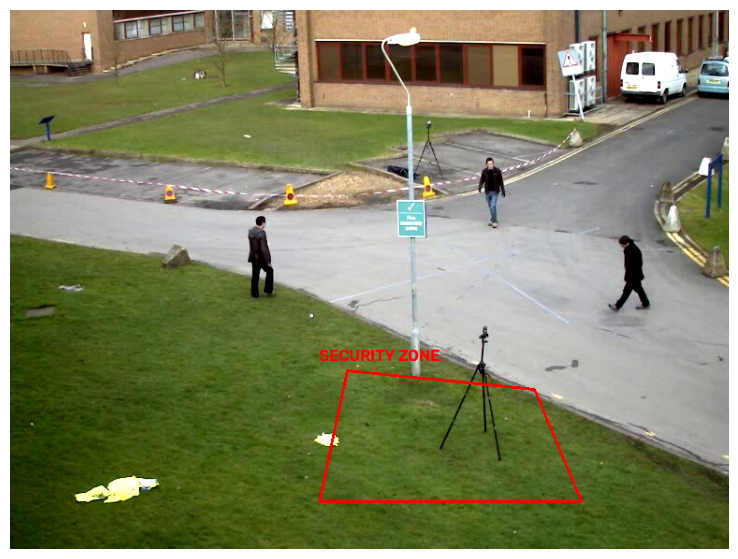

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

source = "images/vtest.avi"
zone = np.array([[360, 385], [560, 405], [610, 525], [330, 525]], np.int32)

cap = cv2.VideoCapture(source)
ret, first = cap.read()
cap.release()
temp = first.copy()
cv2.polylines(temp, [zone], True, (0, 0, 255), 2)
cv2.putText(temp, "SECURITY ZONE", (330, 375), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
plt.figure(figsize=(10, 7)); plt.imshow(cv2.cvtColor(temp, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

In [2]:
def add_bag(frame):
    x, y = 375, 445
    cv2.rectangle(frame, (x, y), (x + 38, y + 30), (25, 35, 70), -1)
    cv2.rectangle(frame, (x, y), (x + 38, y + 30), (10, 15, 30), 2)
    cv2.rectangle(frame, (x + 12, y - 8), (x + 26, y), (10, 15, 30), 2)
    return frame

### main loop
- background subtraction (MOG2) to get moving / new objects
- threshold 200 to remove shadows (shadows are 127 in MOG2)
- opening and closing to clean the mask
- findContours = boundary of each object
- alarm if bottom point of object is in zone or object overlaps zone a lot

first 60 frames are just for learning the background. after that learning rate is very low so the bag doesnt disappear into background

In [3]:
cap = cv2.VideoCapture(source)
fps = cap.get(cv2.CAP_PROP_FPS)
W = int(cap.get(3))
H = int(cap.get(4))
out = cv2.VideoWriter("outputs/task8_security.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))

zone_mask = np.zeros((H, W), np.uint8)
cv2.fillPoly(zone_mask, [zone], 255)

bg = cv2.createBackgroundSubtractorMOG2(history=300, varThreshold=40, detectShadows=True)
k1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

alarms = []
objects = []
saved = {}
log = []
was_alarm = False
n = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    if n >= 450:
        frame = add_bag(frame)

    if n < 60:
        fg = bg.apply(frame)
    else:
        fg = bg.apply(frame, learningRate=0.0001)
    _, fg = cv2.threshold(fg, 200, 255, cv2.THRESH_BINARY)
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, k1)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, k2)
    fg = cv2.dilate(fg, None, iterations=2)

    contours, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    res = frame.copy()
    in_zone = 0
    total = 0
    if n >= 60:
        for c in contours:
            if cv2.contourArea(c) < 350:
                continue
            total += 1
            x, y, w, h = cv2.boundingRect(c)
            foot = (x + w // 2, y + h)
            foot_in = cv2.pointPolygonTest(zone, foot, False) >= 0
            obj = fg[y:y+h, x:x+w]
            overlap = np.count_nonzero(obj & zone_mask[y:y+h, x:x+w]) / max(1, np.count_nonzero(obj))
            if foot_in or overlap > 0.3:
                color = (0, 0, 255)
                in_zone += 1
            else:
                color = (0, 255, 0)
            cv2.drawContours(res, [c], -1, color, 2)
            cv2.rectangle(res, (x, y), (x + w, y + h), color, 1)

    if in_zone > 0:
        cv2.polylines(res, [zone], True, (0, 0, 255), 3)
        cv2.rectangle(res, (0, 0), (W, 45), (0, 0, 255), -1)
        cv2.putText(res, "ALARM! object in security zone", (10, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
        if not was_alarm:
            log.append("alarm started at frame " + str(n) + " (" + str(round(n / fps, 1)) + " sec)")
    else:
        cv2.polylines(res, [zone], True, (0, 200, 255), 2)
        cv2.putText(res, "clear", (10, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 200, 0), 2)
        if was_alarm:
            log.append("alarm stopped at frame " + str(n))
    was_alarm = in_zone > 0

    alarms.append(in_zone)
    objects.append(total)
    out.write(res)
    if n in [200, 455, 560, 610]:
        saved[n] = (res, fg)
    n += 1

cap.release()
out.release()
print("frames:", n)
print("frames with alarm:", sum(1 for a in alarms if a > 0))
for line in log:
    print(line)

frames: 795
frames with alarm: 345
alarm started at frame 450 (45.0 sec)


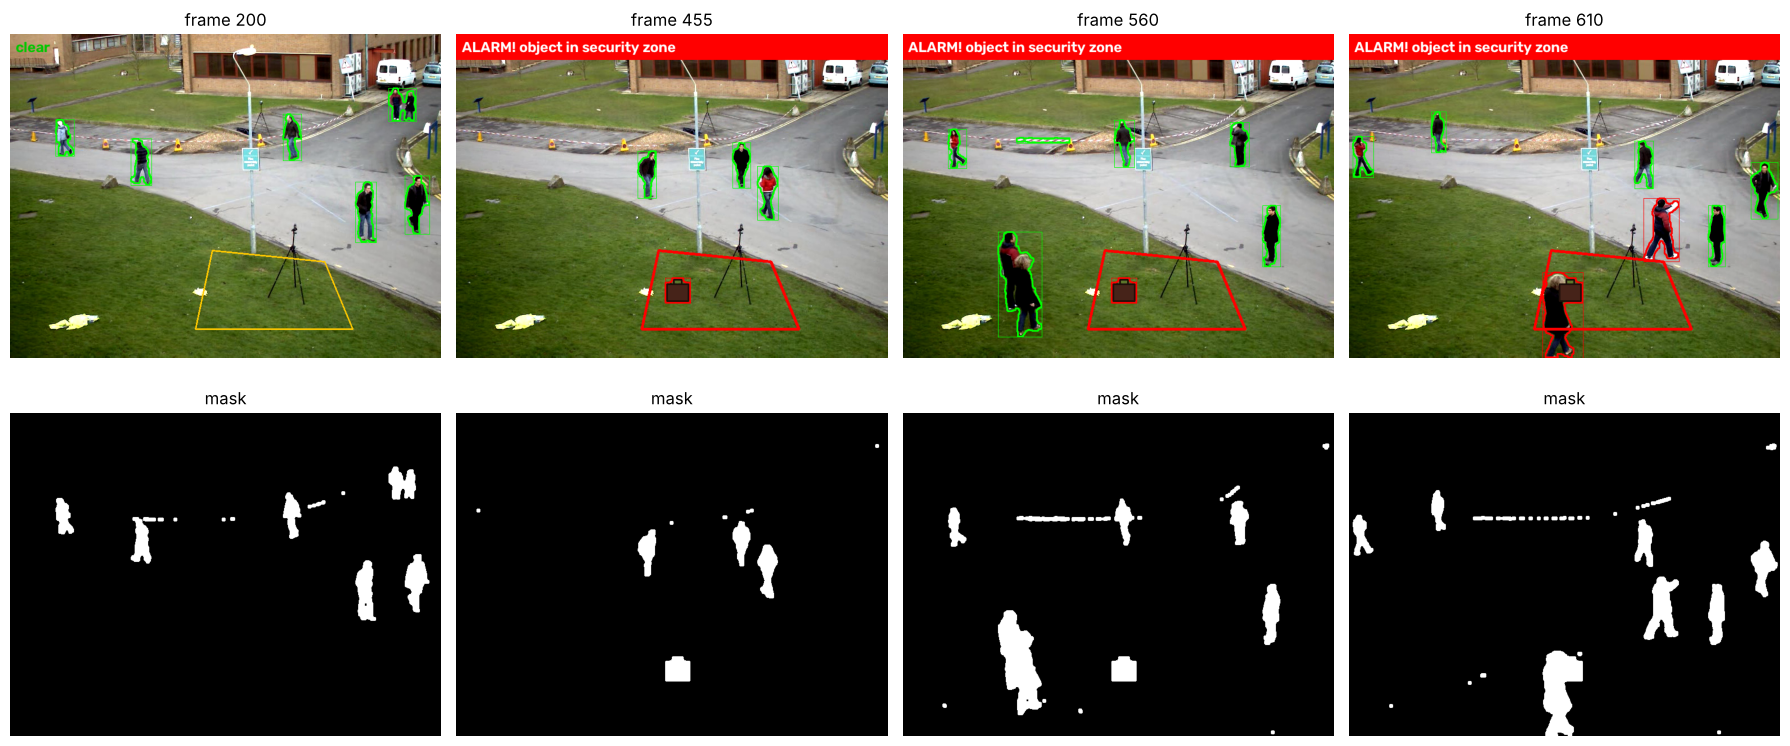

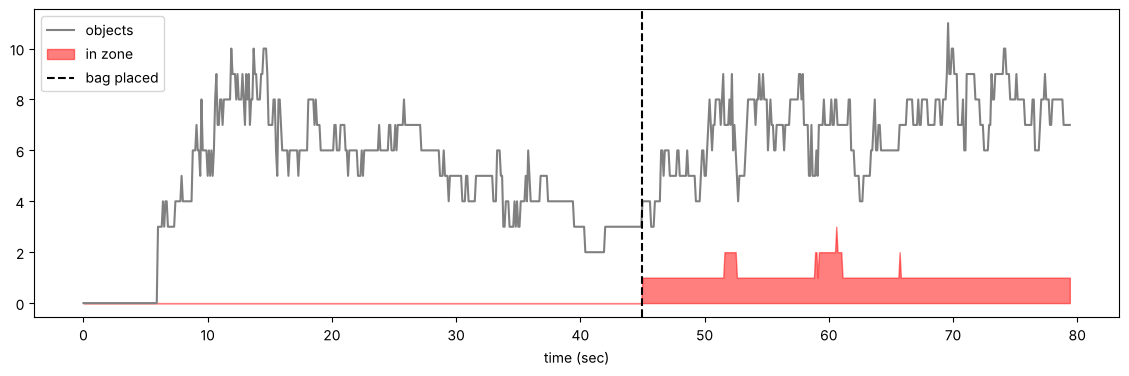

In [4]:
plt.figure(figsize=(18, 8))
i = 1
for k in saved:
    plt.subplot(2, 4, i); plt.imshow(cv2.cvtColor(saved[k][0], cv2.COLOR_BGR2RGB)); plt.title("frame " + str(k)); plt.axis("off")
    plt.subplot(2, 4, i + 4); plt.imshow(saved[k][1], cmap="gray"); plt.title("mask"); plt.axis("off")
    i += 1
plt.tight_layout()
plt.savefig("outputs/task8_frames.png")
plt.show()

t = np.arange(len(alarms)) / fps
plt.figure(figsize=(14, 4))
plt.plot(t, objects, color="gray", label="objects")
plt.fill_between(t, 0, alarms, color="red", alpha=0.5, label="in zone")
plt.axvline(450 / fps, color="k", ls="--", label="bag placed")
plt.xlabel("time (sec)")
plt.legend()
plt.show()